In [1]:
const c_s = 2.99798458E8
const ħ = 1.054571E-34
const kb = 1.3806452E-23
const ϵ0 =  8.85418E-12
const q_c = 1.60217663e-19
const m_e = 9.11e-31
const μB = 1.39962449361e10

1.39962449361e10

In [2]:
using Base.Threads
using Distributions
using Random

function potentialωU(x, y, z, ω::AbstractVector{<:Real}, wavelength::T, mass::T) where T# Assumes x,y plane is radial plane and effectively a single beam 
    ωr, ωz  = ω
    
   waist = ωr / ωz * (1 / (pi * sqrt(2))) * wavelength
   
   zr = pi * waist^2 / wavelength
   U0 = 1 / 4 * mass * waist^2 * ωr^2
   return -U0*(1 - 2*(x^2 + y^2)/(waist^2) - (z/zr)^2)
end

function potentialω(x, y, z, ω::AbstractVector{<:Real}, mass::T) where T
    return @inbounds 1/2*mass*(ω[1]^2*(x^2 + y^2) + ω[2]^2 *z^2)
end
function generateAtomsREJ_P(Potential,mass,  range, temp, atomNum; edims = 0 )
    kb = 1.3806452E-23
    coordList = Vector{Any}[]
    lockit = ReentrantLock()

    @threads for _ in 1:atomNum
        localCoordList = []
        rng = MersenneTwister(Int(floor((rand(Uniform(1, 1e7))))))

        while length(localCoordList) < 1
            coordZ = [rand(rng, Uniform(-range[1], range[1])), rand(rng, Uniform(-range[2], range[2])), rand(rng, Uniform(-range[3], range[3]))] 
            
            PE = (Potential(coordZ...) - Potential([0.0, 0.0, 0.0]...))

            if exp(-PE/(kb*temp)) > rand(rng)
                vel_c = sampleVelocities_BD(temp,mass,  1, rng)[1]
                push!(localCoordList, [coordZ...,vel_c..., zeros(Float64, edims)...])
            end
        end

        lock(lockit) do
            append!(coordList, localCoordList)
        end
    end

    coordList
end
"""
Generate atoms in thermal equilibrium in a harmonic trap using Gaussian distributions.

For a 3D harmonic oscillator with frequencies ω = [ωx, ωy, ωz]:
- Position: σ_i = sqrt(k_B*T / (m*ω_i^2))
- Velocity: σ_v = sqrt(k_B*T / m) (same for all directions)

Parameters:
- ω: trap frequencies [ωx, ωy, ωz] or [ωr, ωz] (will use [ωr, ωr, ωz])
- mass: particle mass
- temp: temperature
- atomNum: number of atoms
- edims: extra dimensions for internal state (default 0)
"""
function generateAtomsGaussian(ω::AbstractVector{<:Real}, mass::Real, temp::Real, atomNum::Int; edims::Int=0)
    kb = 1.3806452E-23
    
    # Handle both [ωr, ωz] and [ωx, ωy, ωz] formats
    if length(ω) == 2
        ωx, ωy, ωz = ω[1], ω[1], ω[2]  # radial is same for x,y
    elseif length(ω) == 3
        ωx, ωy, ωz = ω[1], ω[2], ω[3]
    else
        error("ω must have length 2 or 3")
    end
    
    # Position standard deviations (from equipartition theorem)
    σx = sqrt(kb * temp / (mass * ωx^2))
    σy = sqrt(kb * temp / (mass * ωy^2))
    σz = sqrt(kb * temp / (mass * ωz^2))
    
    # Velocity standard deviation (Maxwell-Boltzmann)
    σv = sqrt(kb * temp / mass)
    
    # Generate positions
    x = randn(atomNum) .* σx
    y = randn(atomNum) .* σy
    z = randn(atomNum) .* σz
    
    # Generate velocities
    vx = randn(atomNum) .* σv
    vy = randn(atomNum) .* σv
    vz = randn(atomNum) .* σv
    
    # Package into the same format as generateAtomsREJ_P
    coordList = []
    for i in 1:atomNum
        push!(coordList, [x[i], y[i], z[i], vx[i], vy[i], vz[i], zeros(Float64, edims)...])
    end
    
    return coordList
end

sampleVelocities_BD(Temp, mass_, atomNum) =sampleVelocities_BD(Temp, mass_, atomNum, 1)
function sampleVelocities_BD(Temp,mass_,  atomNum, rng)
    kb = 1.3806452E-23
    scale = sqrt(kb * Temp /mass_)
    vx, vy, vz = randn(rng, atomNum) * scale, randn(rng, atomNum) * scale, randn(rng, atomNum) * scale
    velList = []
    for i in 1:atomNum
        push!(velList, [vx[i], vy[i], vz[i]])
    end
    return velList
end

force(x, y, z, pot::Function; dl = 1e-8) = -([pot(x + dl, y, z) - pot(x, y, z), pot(x, y + dl, z) - pot(x, y, z), pot(x, y, z + dl) - pot(x, y, z )]/dl)
@inline force_harmonic(x::T,y::T,z::T, ωr::T, ωz::T, mass::T) where {T} =
    (-mass*ωr^2*x, -mass*ωr^2*y, -mass*ωz^2*z)

#const ωOI = 2π .* (284.0, 32.0)
#const moleculeMass = (40 + 87)*1.66054e-27

@inline forceOI2(x::Float64, y::Float64, z::Float64, t::Float64) =
    force_harmonic(x,y,z, ωOI[1], ωOI[2], moleculeMass)



forceOI2 (generic function with 1 method)

In [3]:
module utils
using LinearAlgebra
using Random
using Statistics
using Distributions


export pol_v, decompose_spherical, project_onto_vector, project_onto_plane, rotation_matrix, get_angle, getSphereVec


const pol_v = Dict("sigma_p" => -1 / sqrt(2) * ComplexF64[1, 1im, 0], "sigma_m" => 1 / sqrt(2) * ComplexF64[1, -1im, 0], "pi" => ComplexF64[0, 0, 1])




function decompose_spherical(pol)
   return ComplexF64[dot(conj(pol_v["pi"]), pol), dot(conj(pol_v["sigma_p"]), pol), dot(conj(pol_v["sigma_m"]), pol)]
end


project_onto_vector(v, n) = dot(v, n / norm(n)) * (n / norm(n))
project_onto_plane(x, n) = x - dot(x, n / norm(n)) * (n / norm(n))




function rotation_matrix(axis, theta)
   axis = axis / norm(axis)
   a = cos(theta / 2)
   b, c, d = -axis * sin(theta / 2)
   return [a*a+b*b-c*c-d*d 2*(b*c-a*d) 2*(b*d+a*c)
       2*(b*c+a*d) a*a+c*c-b*b-d*d 2*(c*d-a*b)
       2*(b*d-a*c) 2*(c*d+a*b) a*a+d*d-b*b-c*c]
end


get_angle(v1, v2) = acos(dot(v1, v2) / (norm(v1) * norm(v2)))


function getSphereVec(n)
   uvec = rand(Normal(), n)
   uvec = uvec / norm(uvec)
   return uvec
end


end

module BeamClass
using ..utils
using LinearAlgebra
export BeamProperties, GaussianBeam, get_Intensity


struct BeamProperties{T}
   Loc::T
   dir::T
   pol
   waist::Float64
   zr::Float64
end


#BeamProperties(Loc::T, dir::T, pol) where {T} = BeamProperties{T}(Loc, dir, pol, 1e10, 1e10)
BeamProperties(Loc::T, dir::T, waist::Float64, wavelength::Float64) where T = BeamProperties{T}(Loc, dir, pol_v["pi"], waist, pi * waist^2 / wavelength)




mutable struct GaussianBeam
   beamStruct::BeamProperties
   I0::Float64
end


function get_Intensity(Beam::GaussianBeam, pos)
   BP = Beam.beamStruct
   r = norm(project_onto_plane(pos- BP.Loc, BP.dir))
   z = norm(project_onto_vector(pos- BP.Loc, BP.dir))
   w(z_i) = BP.waist * sqrt(1 + (z_i / BP.zr)^2)
   I = Beam.I0 * (BP.waist / w(z))^2 * exp(-2 * r^2 / (w(z)^2))
   return I
end


end

Main.BeamClass

In [4]:
using ..BeamClass
using ..utils


const wL = 1064e-9

const H_Loc_1::Vector{Float64} = [0, 0, 0]
#H_Loc_2::Vector{Float64} = [0, 0, -7.5e-6]
#H_Loc_3::Vector{Float64} = [0, 0, 7.5e-6]
const V_Loc::Vector{Float64} = [0, 0e-6, 0]
const BeamPropComb = [BeamProperties(H_Loc_1, [0.0, 1.0, 0.0], 35e-6, wL),  BeamProperties(V_Loc, [0.0, -sin(70*pi/180), cos(70*pi/180)], 100e-6, wL)]
const BeamComb::Vector{GaussianBeam} = [GaussianBeam(BeamPropComb[1], 1.0), GaussianBeam(BeamPropComb[2], 1.0)]


2-element Vector{GaussianBeam}:
 GaussianBeam(BeamProperties{Vector{Float64}}([0.0, 0.0, 0.0], [0.0, 1.0, 0.0], ComplexF64[0.0 + 0.0im, 0.0 + 0.0im, 1.0 + 0.0im], 3.5e-5, 0.0036169652261724586), 1.0)
 GaussianBeam(BeamProperties{Vector{Float64}}([0.0, 0.0, 0.0], [0.0, -0.9396926207859083, 0.3420201433256688], ComplexF64[0.0 + 0.0im, 0.0 + 0.0im, 1.0 + 0.0im], 0.0001, 0.029526246744264968), 1.0)

In [5]:
using PhysicalConstants.CODATA2018
# Constants
h = PlanckConstant.val
function makePotential(Intensity::Vector{Float64}, BeamComb)
    function getPotential(x::T, y::T, z::T) where T<:Float64
        polarizibility = 5.53e-5 * 1e6 * h *1e-4

        pos::Vector{Float64} = [x, y, z]
        totalIntensity = 0
        
        for (beam, beamIntensity) in enumerate(Intensity)
            
            totalIntensity += beamIntensity*get_Intensity(BeamComb[beam], pos)
        end
        -polarizibility*totalIntensity
    end
    return getPotential
end

function makePotential2(Intensity::Vector{Float64}, BeamComb)
    # Pre-compute constants and beam parameters
    polarizibility = 5.53e-5 * 1e6 * h * 1e-4
    n_beams = length(Intensity)
    
    # Pre-compute normalized directions and other beam parameters
    beam_params = [(
        loc_x = BeamComb[i].beamStruct.Loc[1],
        loc_y = BeamComb[i].beamStruct.Loc[2],
        loc_z = BeamComb[i].beamStruct.Loc[3],
        dir = let d = BeamComb[i].beamStruct.dir
            dn = sqrt(d[1]^2 + d[2]^2 + d[3]^2)
            (d[1]/dn, d[2]/dn, d[3]/dn)
        end,
        waist = BeamComb[i].beamStruct.waist,
        waist² = BeamComb[i].beamStruct.waist^2,
        inv_zr = 1 / BeamComb[i].beamStruct.zr,
        I0 = BeamComb[i].I0,
        intensity = Intensity[i]
    ) for i in 1:n_beams]
    
    @inline function getPotential(x::Float64, y::Float64, z::Float64)
        totalIntensity = 0.0
        
        @inbounds for params in beam_params
            # Displacement from beam center
            Δx = x - params.loc_x
            Δy = y - params.loc_y
            Δz = z - params.loc_z
            
            # Axial distance (project onto beam direction)
            z_ax = Δx * params.dir[1] + Δy * params.dir[2] + Δz * params.dir[3]
            
            # Radial distance squared
            z_proj_x = z_ax * params.dir[1]
            z_proj_y = z_ax * params.dir[2]
            z_proj_z = z_ax * params.dir[3]
            
            r² = (Δx - z_proj_x)^2 + (Δy - z_proj_y)^2 + (Δz - z_proj_z)^2
            
            # Beam waist at axial position
            zr_ratio² = (z_ax * params.inv_zr)^2
            w² = params.waist² * (1 + zr_ratio²)
            
            # Gaussian intensity
            I = params.I0 * params.intensity * (params.waist² / w²) * exp(-2 * r² / w²)
            
            totalIntensity += I
        end
        
        return -polarizibility * totalIntensity
    end
    
    return getPotential
end

makePotential2 (generic function with 1 method)

In [6]:
using BenchmarkTools
getIntensity::Vector{Float64} = [5.051656883498337, 2.0133327108188115]*1e7
potentialBeam2 = makePotential2(getIntensity, BeamComb)
@btime potentialBeam2(1e-6, 0.0, 0.0)

  33.031 ns (1 allocation: 16 bytes)


-2.585598185464294e-28

In [7]:
using SparseArrays

const moleculeMass = (40 + 87)*1.66054E-27

rangeSpawn = [ 100e-6, 100e-6, 400e-6]
initCond = generateAtomsREJ_P(potentialBeam2, moleculeMass, rangeSpawn, 500e-9, 10000, edims = 2);
initMatMol = hcat(initCond...)

8×10000 Matrix{Float64}:
 -1.35429e-6   1.73054e-7    6.32567e-6   …   2.31039e-6  -2.59597e-6
  1.76135e-5  -6.46365e-6    3.29584e-5      -3.21555e-5   3.3393e-5
 -2.72335e-6  -3.1306e-6     4.60251e-6       1.25016e-7  -1.98091e-7
  0.00458112   0.00248479   -0.00260234       0.0043505    0.000223166
  0.00569758   0.000824849   0.00520377       0.00436067   0.00189665
 -0.00675201   0.000898774   0.000256977  …  -0.00231918  -0.00852828
  0.0          0.0           0.0              0.0          0.0
  0.0          0.0           0.0              0.0          0.0

In [8]:
temp = [mean(initMatMol[i, : ].^2 ./ kb .* moleculeMass) for i = 4:6]
trapFreq = [1/(std(initMatMol[i, : ] ./ sqrt.(temp[i]*kb ./ moleculeMass))) for i = 1:3]
#velmean = mean([norm(P.vel[:, i ]) for i in 1:P.Na]  )

println("Temperature $(temp*1e9) K")
println("Trap Frequencys $(trapFreq ./ (2pi)) Hz")
#tmotion = minimum(2*pi ./ trapFreq)

Temperature [490.6479106141437, 505.039665993605, 507.45768602921027] K
Trap Frequencys [262.57338178212603, 21.323587783180194, 260.20700872659177] Hz


In [9]:
using BenchmarkTools
polarizibility = 5.53e-5 * 1e6 * h * 1e-4
getIntensityHigh::Vector{Float64} = [130.16280729349387,  3.3555545180313526]*1e7 #./(0.6)
potentialBeamHigh = makePotential2(getIntensityHigh, BeamComb)
intDist =  -1*[potentialBeamHigh(initMatMol[1:3, mol]...) for mol = 1:size(initMatMol, 2)] ./ polarizibility*1e-7
intMean, intStd =  mean(intDist), std(intDist)
intArray = [(intMean - 5*intStd):intStd/10:(intMean + 5*intStd)...]*1e7

101-element Vector{Float64}:
 1.0380145436498384e9
 1.0429369847069643e9
 1.0478594257640902e9
 1.0527818668212159e9
 1.0577043078783417e9
 1.0626267489354676e9
 1.0675491899925934e9
 1.0724716310497192e9
 1.0773940721068451e9
 1.082316513163971e9
 ⋮
 1.4908791209054148e9
 1.4958015619625409e9
 1.5007240030196667e9
 1.5056464440767925e9
 1.510568885133918e9
 1.515491326191044e9
 1.52041376724817e9
 1.5253362083052957e9
 1.5302586493624215e9

In [10]:
#using Revise
include("diatomic.jl")

using .diatomic_jl.MoleculeTypes
using .diatomic_jl

import .diatomic_jl.calculate: transition_dipole_moment
import .diatomic_jl.Hamiltonian: getDipoleMatrix

┌ Warning: It looks like the Kaleido process is not responding since 10 seconds. 
│ The unresponsive process will be killed, but this means that you will not be able to save figures using `savefig`.
│ 
│ Alternatively, you might try using a longer timeout to check if the process is not responding by passing the desired value in seconds using the `timeout` kwarg when calling `PlotlyKaleido.start` or `PlotlyKaleido.restart`
└ @ PlotlyKaleido /Users/jluke/.julia/packages/PlotlyKaleido/hHnQW/src/PlotlyKaleido.jl:38


In [11]:
MoleculeOperator = Molecule.generateMolecule(K40Rb87T, 2)
beams = Dict("B" =>Hamiltonian.OpticalBeam([1.0, 0.0, 0.0], [0, 0.0, 1.0])) # kVector, Polarization
Hmol = Hamiltonian.generateHamiltonian(MoleculeOperator, dirE = [0.0, 1.0, 0.0],  Beams = beams);

In [12]:
IntensityScan = solve.scanIntensity(Hmol, 50e-4, 47e2, [0, intArray...]);
using LinearAlgebra

UnitaryDict = Dict()
stateOIind = 8
dipOp =  getDipoleMatrix(Hmol.MolOp)
for intensitySol in  IntensityScan
    Hmicr = zeros(Float64, size(dipOp[1]))
    N_product = Hmol.MolOp.N[1:3] * Hmol.MolOp.N[1:3]
           
    UnitaryDict[intensitySol.Intensity[1]] = (eigvals_ = intensitySol.val, eigvecs_= intensitySol.vec, stateOI = intensitySol.vec[:, stateOIind],
    dipOpU = [adjoint(intensitySol.vec)*dip*(intensitySol.vec) for dip in dipOp], 
    Hmicr = Hmicr, 
    H0 = Diagonal(intensitySol.val))
    
end



In [ ]:
plotting.plotIntensityScan(Hmol, IntensityScan, N = [1])
#axhline(0)
#figure(gcf())

In [13]:



const Ecomp1::Vector{Float64}= [0, 0, 1]
const axisX::Vector{Float64} = [1, 0, 0]
const axisZ::Vector{Float64} = [0, 0, 1]
rotationAngle = 81.5
Erot = rotation_matrix(axisX, rotationAngle*pi/180)*Ecomp1
ErotZ = rotation_matrix(axisZ, 90*pi/180)*Erot


3-element Vector{Float64}:
 0.9890158633619168
 2.1960563664478557e-16
 0.14780941112961066

In [14]:
using LinearAlgebra

UnitaryDict = Dict()
stateOIind = 8
dipOp =  getDipoleMatrix(Hmol.MolOp)
for intensitySol in  IntensityScan
    Hmicr = zeros(Float64, size(dipOp[1]))
    N_product = Hmol.MolOp.N[1:3] * Hmol.MolOp.N[1:3]
    
    UnitaryDict[intensitySol.Intensity[1]] = (eigvals_ = intensitySol.val, eigvecs_= intensitySol.vec, stateOI = intensitySol.vec[:, stateOIind],
    dipOpU = [adjoint(intensitySol.vec)*dip*(intensitySol.vec) for dip in dipOp], 
    Hmicr = Hmicr, 
    H0 = Diagonal(intensitySol.val))
    
end



In [87]:
Ecomp1
decompose_spherical(Erot)

3-element Vector{ComplexF64}:
 0.04361938736533617 + 0.0im
                 0.0 - 0.7064337722128922im
                 0.0 - 0.7064337722128922im

In [15]:

    rotationAngle = 88.2
    Erot = rotation_matrix(axisX, rotationAngle*pi/180)*Ecomp1
    Ecomp = normalize!(Erot) 
    sigmaPcomp = abs(decompose_spherical(Erot)[3])#/sum(abs.(decompose_spherical(Erot)))
    Picomp = abs(decompose_spherical(Erot)[1])#/sum(abs.(decompose_spherical(Erot)))
    sigmaPcomp/Picomp

22.500502611768212

In [144]:
norm(decompose_spherical(Erot))

1.0

In [16]:
using LinearAlgebra

function simulateSpectrum(mField,statePop,popValues,  driveTime , eigvals, eigvecs, Hmol)
    DebyeSI = 3.33564e-30
    truncate = 144

    dipOp =  getDipoleMatrix(Hmol.MolOp)
    Hmicr = zeros(Float64, size(dipOp[1]))
    N_product = Hmol.MolOp.N[1:3] * Hmol.MolOp.N[1:3]



    dipOpU = [adjoint(eigvecs)*dip*(eigvecs) for dip in dipOp]
    Hmicr[findall(x->isapprox(x, 2), N_product)] .= 1
    H0 = Diagonal(eigvals)


    rotationAngle = 88.2
    Erot = rotation_matrix(axisX, rotationAngle*pi/180)*Ecomp1
    Ecomp = normalize!(Erot) 
    sigmaPcomp = abs(decompose_spherical(Erot)[3])#/sum(abs.(decompose_spherical(Erot)))
    PiTime = (398e-6)/2*10
    rabiRate = 1/(2*PiTime);
    #println((1/sigmaPcomp))
    E_field_hz = rabiRate/(0.33*DebyeSI)*(1/sigmaPcomp)#*(1/2)





    E_field_res = E_field_hz*Ecomp
    setTime = driveTime
    

    popN1 = zeros(Float64, 36, length(mFieldScan))
    statesOI = [1:144...]

    for (i, m_i) in enumerate(mFieldScan)
        #H0_i = H0 - m_i*Hmicr
        #indsOI = findall(x-> abs(x)< threshold, diag(H0_i))

        H = 2*pi*(H0 - m_i*Hmicr + sum(E_field_res.*dipOpU)/2)
        Htrunc = H[statesOI, statesOI]


        Uprop = exp(-1im * Htrunc * setTime)
        for (_ind, stateGS)  in  enumerate(statePop)

            stateInit = zeros(Float64, size(eigvecs, 1))
            stateInit[stateGS] = popValues[_ind]
            stateFinal = adjoint(Uprop)*stateInit[1:truncate][statesOI]
        

            popN1[stateGS, i] = sum(abs2.(stateFinal[37:144]))
        end
    end

    return popN1
end

    

simulateSpectrum (generic function with 1 method)

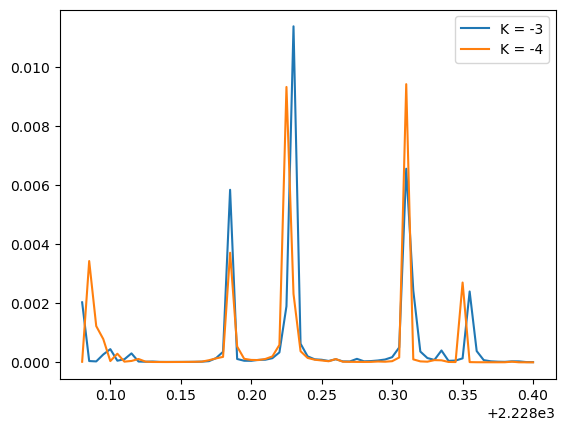

In [17]:
mFieldScan = [2228.08:0.005:2228.4...]*1e6
statePop4 = [1, 8, 16,  24]
popValues4 = ones(size(statePop4))#[1]
statePop = [2, 10,18,  26]

#statePop = [2]
popValues = ones(size(statePop))#[1]
driveTime = 200e-6

using PyPlot
res = simulateSpectrum(mFieldScan, statePop,popValues,  driveTime, IntensityScan[1].val, IntensityScan[1].vec, Hmol)
res2 = simulateSpectrum(mFieldScan, statePop4,popValues4,  driveTime, IntensityScan[1].val, IntensityScan[1].vec, Hmol)
clf()
plot(mFieldScan*1e-6, sum(res, dims = 1)',  label = "K = -3")
plot(mFieldScan*1e-6, sum(res2, dims = 1)', label="K = -4")
legend()
figure(gcf())

start 2227.88


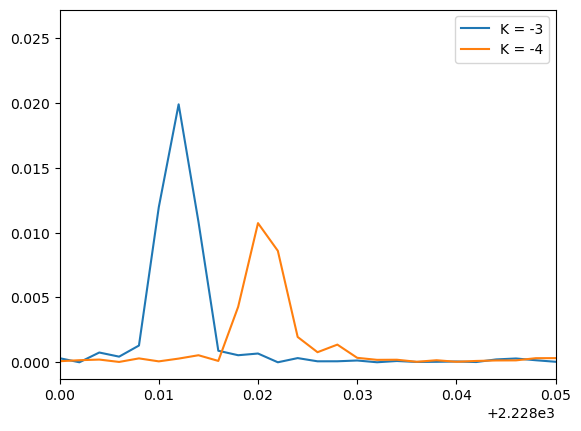

In [43]:
shift = 200
mFieldScan = [2228.08:0.002:2228.4...]*1e6 .- shift*1e6*1e-3
println("start $(minimum(mFieldScan)*1e-6)")
statePop4 = [8,  16,  24]
popValues4 = ones(size(statePop4))#[1]
statePop =  [26]#[18]

#statePop = [2]
popValues = ones(size(statePop))#[1]
driveTime = 200e-6

using PyPlot
res = simulateSpectrum(mFieldScan, statePop,popValues,  driveTime, IntensityScan[1].val, IntensityScan[1].vec, Hmol)
res2 = simulateSpectrum(mFieldScan, statePop4,popValues4,  driveTime, IntensityScan[1].val, IntensityScan[1].vec, Hmol)
clf()
plot(mFieldScan*1e-6, sum(res, dims = 1)',  label = "K = -3")
plot(mFieldScan*1e-6, sum(res2, dims = 1)', label="K = -4")
xlim([2228.0, 2228.05])
legend()
figure(gcf())


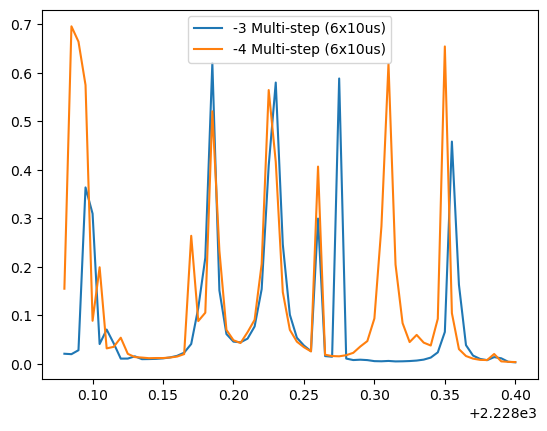

In [ ]:
mFieldScan = [2228.08:0.005:2228.4...]*1e6
statePop4 = [1, 8, 16,  24]
popValues4 = ones(size(statePop4))#[1]
statePop = [2, 10,18,  26]
popValues = ones(size(statePop))#[1]

# Parameters
step_duration = 10e-6  # 10 us
num_steps = 200          # 6 events
det_fidelity = 0.01    # e.g., 80% detection efficiency

# Call the new function
res_multi = simulateMultiStepSpectrum(
    mFieldScan, 
    statePop, 
    popValues, 
    step_duration, 
    num_steps, 
    det_fidelity, # New arg
    IntensityScan[1].val, 
    IntensityScan[1].vec, 
    Hmol
)

res_multi2 = simulateMultiStepSpectrum(
    mFieldScan, 
    statePop4, 
    popValues4, 
    step_duration, 
    num_steps, 
    det_fidelity, # New arg
    IntensityScan[1].val, 
    IntensityScan[1].vec, 
    Hmol
)


# Plotting
clf()
plot(mFieldScan*1e-6, sum(res_multi, dims=1)', label="-3 Multi-step (6x10us)")
plot(mFieldScan*1e-6, sum(res_multi2, dims=1)', label="-4 Multi-step (6x10us)")
legend()
figure(gcf())

In [20]:
using LinearAlgebra

function simulateMultiStepSpectrum(mFieldScan, statePop, popValues, stepTime, n_steps, fidelity, eigvals, eigvecs, Hmol)
    DebyeSI = 3.33564e-30
    truncate = 144
    
    # --- Setup Operators ---
    dipOp = getDipoleMatrix(Hmol.MolOp)
    Hmicr = zeros(Float64, size(dipOp[1]))
    N_product = Hmol.MolOp.N[1:3] * Hmol.MolOp.N[1:3]

    # Transform dipoles to eigenbasis
    dipOpU = [adjoint(eigvecs) * dip * (eigvecs) for dip in dipOp]
    
    # Identify N=2 couplings (from your original code logic) for Hmicr
    Hmicr[findall(x -> isapprox(x, 2), N_product)] .= 1
    H0 = Diagonal(eigvals)

    # --- Electric Field / Rabi Setup ---
    rotationAngle = 88.2
    # Assuming axisX, Ecomp1, decompose_spherical are defined globally or passed in 
    # (kept as is from your snippet, though usually these should be args)
    Erot = rotation_matrix(axisX, rotationAngle * pi/180) * Ecomp1
    Ecomp = normalize!(Erot) 
    sigmaPcomp = abs(decompose_spherical(Erot)[3])
    
    PiTime = (177e-6)/2
    rabiRate = 1/(2*PiTime)
    E_field_hz = rabiRate/(0.33*DebyeSI)*(1/sigmaPcomp)
    E_field_res = E_field_hz * Ecomp
    
    # --- Simulation Storage ---
    # We will store the ACCUMULATED signal (total population detected over all steps)
    totalSignal = zeros(Float64, 36, length(mFieldScan))
    
    # Indices for the N=1 manifold (Target)
    # Assuming 1-36 are N=0, and 37-144 are N=1
    indsN1 = 37:144 
    statesOI = [1:144...] 

    # Pre-calculate the projection scaling factor
    # If fidelity is 1.0, we project out N=1 completely (amplitude -> 0)
    # If fidelity is 0.0, we leave it alone.
    proj_scaler = sqrt(1.0 - fidelity)

    for (i, m_i) in enumerate(mFieldScan)
        # Construct Hamiltonian for this frequency
        # Note: Using your RWA definition H = 2*pi*(H0 - m_i*Hmicr + Rabi)
        H = 2*pi*(H0 - m_i*Hmicr + sum(E_field_res .* dipOpU)/2)
        Htrunc = H[statesOI, statesOI]

        # Propagator for a SINGLE step
        Ustep = exp(-1im * Htrunc * stepTime)
        
        for (_ind, stateGS) in enumerate(statePop)
            # Initialize state
            psi = zeros(ComplexF64, size(eigvecs, 1))
            psi[stateGS] = popValues[_ind] # Assuming sqrt(pop) if these are amplitudes, but code implies popValues are 1.
            
            # Extract relevant subspace
            psi_curr = psi[statesOI]
            
            accumulated_pop = 0.0

            # --- The Multi-Step Loop ---
            for step in 1:n_steps
                # 1. Evolve for stepTime
                psi_curr = Ustep * psi_curr
                
                # 2. Measure Population in N=1
                pop_in_N1 = sum(abs2, psi_curr[indsN1])
                
                # 3. Accumulate Signal (Simulation of measurement)
                accumulated_pop += pop_in_N1 * fidelity
                
                # 4. Project/Collapse State (Back-action)
                # Scale the N=1 amplitudes down by sqrt(1-fidelity)
                psi_curr[indsN1] .*= proj_scaler
            end

            totalSignal[stateGS, i] = accumulated_pop
        end
    end

    return totalSignal
end

simulateMultiStepSpectrum (generic function with 1 method)

In [ ]:
using LinearAlgebra

function simulateMultiStepSpectrum2(mFieldScan, statePop, popValues, firstPulseTime, stepTime, n_steps, fidelity, eigvals, eigvecs, Hmol)
    DebyeSI = 3.33564e-30
    truncate = 144
    
    # --- Setup Operators ---
    dipOp = getDipoleMatrix(Hmol.MolOp)
    Hmicr = zeros(Float64, size(dipOp[1]))
    N_product = Hmol.MolOp.N[1:3] * Hmol.MolOp.N[1:3]

    dipOpU = [adjoint(eigvecs) * dip * (eigvecs) for dip in dipOp]
    
    # Identify N=2 couplings for Hmicr
    Hmicr[findall(x -> isapprox(x, 2), N_product)] .= 1
    H0 = Diagonal(eigvals)

    # --- Electric Field / Rabi Setup ---
    rotationAngle = 88.2
    # Assuming standard setup variables (axisX, Ecomp1) are available in scope
    Erot = rotation_matrix(axisX, rotationAngle * pi/180) * Ecomp1
    Ecomp = normalize!(Erot) 
    sigmaPcomp = abs(decompose_spherical(Erot)[3])
    
    PiTime = (398e-6)/2
    rabiRate = 1/(2*PiTime)
    E_field_hz = rabiRate/(0.33*DebyeSI)*(1/sigmaPcomp)
    E_field_res = E_field_hz * Ecomp
    
    # --- Simulation Storage ---
    totalSignal = zeros(Float64, 36, length(mFieldScan))
    indsN1 = 37:144 
    statesOI = [1:144...] 
    
    # Projection scalar
    proj_scaler = sqrt(1.0 - fidelity)

    for (i, m_i) in enumerate(mFieldScan)
        # Hamiltonian construction
        H = 2*pi*(H0 - m_i*Hmicr + sum(E_field_res .* dipOpU)/2)
        Htrunc = H[statesOI, statesOI]

        # Calculate Propagators (Unitary evolution matrices)
        # We need two now: one for the initial pulse, one for the repeating steps
        U_first = exp(-1im * Htrunc * firstPulseTime)
        U_step  = exp(-1im * Htrunc * stepTime)
        
        for (_ind, stateGS) in enumerate(statePop)
            # Initialize state
            psi = zeros(ComplexF64, size(eigvecs, 1))
            psi[stateGS] = popValues[_ind] 
            psi_curr = psi[statesOI]
            
            accumulated_pop = 0.0

            # --- 1. The First Pulse Event ---
            psi_curr = U_first * psi_curr
            
            # Measure & Project (First Event)
            pop_in_N1 = sum(abs2, psi_curr[indsN1])
            accumulated_pop += pop_in_N1 * fidelity
            psi_curr[indsN1] .*= proj_scaler

            # --- 2. The Subsequent Loop ---
            for step in 1:n_steps
                psi_curr = U_step * psi_curr
                
                # Measure & Project (Subsequent Events)
                pop_in_N1 = sum(abs2, psi_curr[indsN1])
                accumulated_pop += pop_in_N1 * fidelity
                psi_curr[indsN1] .*= proj_scaler
            end

            totalSignal[stateGS, i] = accumulated_pop
        end
    end

    return totalSignal
end

simulateMultiStepSpectrum2 (generic function with 1 method)

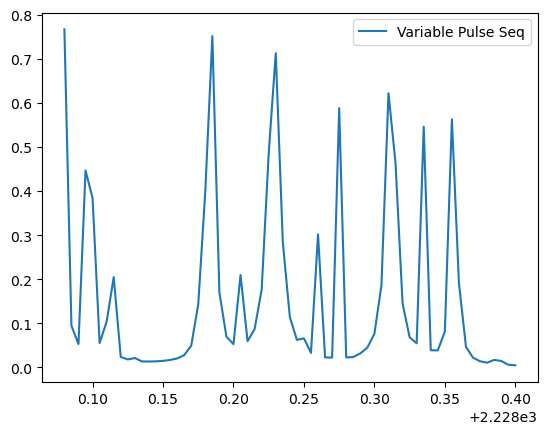

In [65]:
# Example Parameters
t_init = 0.5*300e-6     # First pulse length (e.g., a Pi pulse)
t_step = 0.5*10e-6        # Subsequent small steps
n_repeats = 300         # Number of small steps following the first one
fidelity = 0.01        # 90% detection efficiency

res_variable = simulateMultiStepSpectrum2(
    mFieldScan, 
    statePop, 
    popValues, 
    t_init,      # New arg: First pulse
    t_step,      # New arg: Step pulse
    n_repeats, 
    fidelity, 
    IntensityScan[1].val, 
    IntensityScan[1].vec, 
    Hmol
)

clf()
plot(mFieldScan*1e-6, sum(res_variable, dims=1)', label="Variable Pulse Seq")
legend()
figure(gcf())

In [ ]:


function simulateSpectrumConst(mField,statePop,popValues,  driveTime , eigvals, eigvecs, Hmol; truncateEnergy = 20e3)
    DebyeSI = 3.33564e-30
    truncate = 144

    dipOp =  getDipoleMatrix(Hmol.MolOp)
    Hmicr = zeros(Float64, size(dipOp[1]))
    N_product = Hmol.MolOp.N[1:3] * Hmol.MolOp.N[1:3]



    dipOpU = [adjoint(eigvecs)*dip*(eigvecs) for dip in dipOp]
    Hmicr[findall(x->isapprox(x, 2), N_product)] .= 1
    H0 = Diagonal(eigvals)


    rotationAngle = 87.5
    Erot = rotation_matrix(axisX, rotationAngle*pi/180)*Ecomp1
    Ecomp = normalize!(Erot) 
    sigmaPcomp = abs(decompose_spherical(Erot)[3])#/sum(abs.(decompose_spherical(Erot)))
    PiTime = (398e-6)/2
    rabiRate = 1/(2*PiTime);
    #println((1/sigmaPcomp))
    E_field_hz = rabiRate/(0.33*DebyeSI)*(1/sigmaPcomp)#*(1/2)





    E_field_res = E_field_hz*Ecomp
    setTime = driveTime
    

    popN1 = zeros(Float64, 36, length(mFieldScan))
    statesOI = [1:144...]

    for (i, m_i) in enumerate(mFieldScan)
        for (_ind, stateGS)  in  enumerate(statePop)
        #H0_i = H0 - m_i*Hmicr
        #indsOI = findall(x-> abs(x)< threshold, diag(H0_i))

            H = 2*pi*(H0 - m_i*Hmicr + sum(E_field_res.*dipOpU)/2 - Diagonal(H0[stateGS, stateGS]*ones(size(H0, 1))) ) 
            
            
            Econst =findall(x-> abs(x) <truncateEnergy,  diag(H ./(2*pi)))
            #println(Econst)

            intConst = intersect(statesOI, Econst)


            
            excitedPopInd = intConst[findall(x->x>36, intConst)]
            groundPopInd = intConst[findfirst(x->x == stateGS,  intConst)]

            statesTruncated = union(groundPopInd, excitedPopInd )
            
            Htrunc = H[statesTruncated, statesTruncated]
            
            
            Uprop = exp(-1im * Htrunc * setTime)
        

            stateInit = zeros(Float64, size(statesTruncated))
            stateInit[1] = popValues[_ind]
            
            stateFinal = adjoint(Uprop)*stateInit#[statesTruncated]
            #println(stateGS)
            #println(stateInit)           

            popN1[stateGS, i] = sum(abs2.(stateFinal[2:end]))
        end
    end

    return popN1
end

    

simulateSpectrumConst (generic function with 1 method)

In [44]:
 length([2228.08:0.005:2228.4...])*6/60

6.5

In [193]:
#mFieldScan = [2228.118]*1e6
mFieldScan = [2228.08:0.001:2228.4...]*1e6

statePop4 = [8, 16,  24]
popValues4 = ones(size(statePop4))#[1]
statePop = [10,18,  26]
popValues = ones(size(statePop))#[1]
driveTime = 200e-6

using PyPlot
res = simulateSpectrumConst(mFieldScan, statePop4,popValues,  driveTime, IntensityScan[1].val, IntensityScan[1].vec, Hmol; truncateEnergy = 10e3)
#res2 = simulateSpectrum(mFieldScan, statePop4,popValues4,  driveTime, IntensityScan[1].val, IntensityScan[1].vec, Hmol)
clf()
plot(mFieldScan*1e-6, sum(res, dims = 1)',  label = "K = -3")
#plot(mFieldScan*1e-6, sum(res2, dims = 1)', label="K = -4")
legend()
figure(gcf())

UndefVarError: UndefVarError: `simulateSpectrumConst` not defined

In [20]:
function wrapIntensity(IntensityDist, IntensityScan, UnitaryDict, Hmol,  mField,statePop,popValues,  driveTime; truncateEnergy = 20e3)
    keysOI =hcat(collect(keys(UnitaryDict))...)# collect(keys(UnitaryDict))
    res = zeros(Float64, length(IntensityDist), length(mField))
    
    N_product = Hmol.MolOp.N[1:3] * Hmol.MolOp.N[1:3]

    Hmicr = zeros(Float64, size(N_product))
    Hmicr[findall(x->isapprox(x, 2), N_product)] .= 1




    for indC in 1:length(IntensityDist)
        IntensityCurrent = IntensityDist[indC]
        
        
        keyInd::Int64 = argmin(abs.(keysOI .- IntensityCurrent))[1]
        dipOpU = UnitaryDict[keysOI[keyInd]].dipOpU

        H0 =  Diagonal(IntensityScan[keyInd].val)

        res[indC, :] = simulateSpectrumWrap(mField,statePop,popValues,  driveTime , Hmicr, H0, dipOpU; truncateEnergy = truncateEnergy)

    end
    return res
end


function simulateSpectrumWrap(mField,statePop,popValues,  driveTime , Hmicr, H0, dipOpU; truncateEnergy = 20e3)
    DebyeSI = 3.33564e-30
    truncate = 144

    




    rotationAngle = 87.5
    Erot = rotation_matrix(axisX, rotationAngle*pi/180)*Ecomp1
    Ecomp = normalize!(Erot) 
    sigmaPcomp = abs(decompose_spherical(Erot)[3])#/sum(abs.(decompose_spherical(Erot)))
    PiTime = (398e-6)
    rabiRate = 1/(2*PiTime);
    #println((1/sigmaPcomp))
    E_field_hz = rabiRate/(0.33*DebyeSI)*(1/sigmaPcomp)#*(1/2)





    E_field_res = E_field_hz*Ecomp
    setTime = driveTime
    

    popN1 = zeros(Float64, 36, length(mFieldScan))
    statesOI = [1:144...]

    for (i, m_i) in enumerate(mFieldScan)
        for (_ind, stateGS)  in  enumerate(statePop)
        #H0_i = H0 - m_i*Hmicr
        #indsOI = findall(x-> abs(x)< threshold, diag(H0_i))

            H = 2*pi*(H0 - m_i*Hmicr + sum(E_field_res.*dipOpU) - Diagonal(H0[stateGS, stateGS]*ones(size(H0, 1))) ) 
            
            
            Econst =findall(x-> abs(x) <truncateEnergy,  diag(H ./(2*pi)))
            #println(Econst)

            intConst = intersect(statesOI, Econst)


            
            excitedPopInd = intConst[findall(x->x>36, intConst)]
            groundPopInd = intConst[findfirst(x->x == stateGS,  intConst)]

            statesTruncated = union(groundPopInd, excitedPopInd )
            
            Htrunc = H[statesTruncated, statesTruncated]
            

            Uprop = exp(-1im * Htrunc * setTime)
        

            stateInit = zeros(Float64, size(statesTruncated))
            stateInit[1] = popValues[_ind]
            
            stateFinal = adjoint(Uprop)*stateInit#[statesTruncated]
            #println(stateGS)
            #println(stateInit)           

            popN1[stateGS, i] = sum(abs2.(stateFinal[2:end]))
        end
    end

    return sum(popN1, dims = 1)#popN1
end

    

simulateSpectrumWrap (generic function with 1 method)

In [21]:
mFieldScan = [2228.08...]*1e6
statePop = [8]
popValues = ones(size(statePop))#[1]

driveTime = 200e-6
wrapIntensity(intDist, IntensityScan, UnitaryDict, Hmol,  mFieldScan,statePop,popValues,  driveTime; truncateEnergy = 20e3)

10000×1 Matrix{Float64}:
 9.188043364499809e-5
 9.188043364499809e-5
 9.188043364499809e-5
 9.188043364499809e-5
 9.188043364499809e-5
 9.188043364499809e-5
 9.188043364499809e-5
 9.188043364499809e-5
 9.188043364499809e-5
 9.188043364499809e-5
 ⋮
 9.188043364499809e-5
 9.188043364499809e-5
 9.188043364499809e-5
 9.188043364499809e-5
 9.188043364499809e-5
 9.188043364499809e-5
 9.188043364499809e-5
 9.188043364499809e-5
 9.188043364499809e-5

In [19]:
using Profile, PProf

@profile  wrapIntensity(intDist, IntensityScan, UnitaryDict, Hmol,  mFieldScan,statePop,popValues,  driveTime; truncateEnergy = 20e3)
pprof(;webport=58692)

"profile.pb.gz"

In [38]:
using Profile, PProf
Profile.clear();
@profile  wrapIntensity_optimized(intDist, IntensityScan, UnitaryDict, Hmol,  mFieldScan,statePop,popValues,  driveTime; truncateEnergy = 20e3)
pprof(;webport=58694)

Main binary filename not available.
Serving web UI on http://localhost:58693


"profile.pb.gz"

In [47]:
mFieldScan = [2228.354...]*1e6
res = wrapIntensity(intDist, IntensityScan, UnitaryDict, Hmol,  mFieldScan,statePop,popValues,  driveTime; truncateEnergy = 20e3)
sum(res)

2.45540321732306e-25

In [90]:
const DebyeSI = 3.33564e-30
function wrapIntensity(IntensityDist, IntensityScan, UnitaryDict, Hmol,  mField,statePop,popValues,  driveTime; truncateEnergy = 20e3)
    keyOI2 = [s.Intensity[1] for s in IntensityScan]#hcat()

    res = zeros(Float64, length(IntensityDist), length(mField))
    
    N_product = Hmol.MolOp.N[1:3] * Hmol.MolOp.N[1:3]

    Hmicr = zeros(Float64, size(N_product))
    Hmicr[findall(x->isapprox(x, 2), N_product)] .= 1


    rotationAngle = 87.5
    Erot = rotation_matrix(axisX, rotationAngle*pi/180)*Ecomp1
    Ecomp = normalize!(Erot) 
    sigmaPcomp = abs(decompose_spherical(Erot)[3])#/sum(abs.(decompose_spherical(Erot)))
    PiTime = (398e-6)
    rabiRate = 1/(2*PiTime);
    #println((1/sigmaPcomp))
    E_field_hz = rabiRate/(0.33*DebyeSI)*(1/sigmaPcomp)#*(1/2)




    
    E_field_res = E_field_hz*Ecomp
    setTime = driveTime
    stateGS = statePop[1]

    @threads for indC in 2:length(IntensityDist)
        IntensityCurrent = IntensityDist[indC]
        
        
        keyInd2::Int64 = argmin(abs.(keyOI2 .- IntensityCurrent))[1]
        dipOpU = UnitaryDict[IntensityScan[keyInd2].Intensity[1]].dipOpU


        H0 =  Diagonal(IntensityScan[keyInd2].val .- IntensityScan[keyInd2].val[stateGS])

        res[indC, :] = simulateSpectrumWrap_buffered(mField,statePop,popValues, driveTime,  E_field_res , Hmicr, H0, dipOpU; truncateEnergy = truncateEnergy)
        
    end
    return res
end


function simulateSpectrumWrap_buffered(
    mField,
    statePop,
    popValues,
    driveTime,
    E_field_res,
    Hmicr,
    H0,
    dipOpU;
    truncateEnergy = 20e3
)
    n_states = size(H0, 1)
    max_trunc_size = 144
    
    # Pre-allocate ALL buffers outside the loop
    H_full = zeros(ComplexF64, n_states, n_states)
    dipole_sum = zeros(ComplexF64, n_states, n_states)
    Htrunc = zeros(ComplexF64, max_trunc_size, max_trunc_size)
    stateInit = zeros(ComplexF64, max_trunc_size)
    stateFinal = zeros(ComplexF64, max_trunc_size)
    statesTruncated = zeros(Int, max_trunc_size)
    
    # Pre-compute dipole sum (constant - doesn't depend on m_i)
    @inbounds for k in 1:3
        @. dipole_sum += E_field_res[k] * dipOpU[k]
    end
    dipole_sum .*= 2π/2 # divide by 2 \omega/2
    
    # Pre-compute H0 part
    H0_part = 2π .* H0
    Hmicr_scaled = 2π .* Hmicr
    threshold = truncateEnergy * 2π
    
    pop_excited = zeros(Float64, length(mField))
    
    @inbounds for (i, m_i) in enumerate(mField)
        for (_ind, stateGS) in enumerate(statePop)
            # Build H_full in-place (REUSE buffer)
            @. H_full = H0_part - m_i * Hmicr_scaled + dipole_sum
            
            # Find truncated states (REUSE buffer)
            statesTruncated[1] = stateGS
            n_trunc = 1
            
            for state in 37:144
                if abs(real(H_full[state, state])) < threshold
                    n_trunc += 1
                    statesTruncated[n_trunc] = state
                end
            end
            #println(H0_part[136, 136]/(2pi)*1e-6)
            #println(H_full[136, 136]/(2pi))
            #println(statesTruncated[1:n_trunc])
            #println(n_trunc)
            # Extract Hamiltonian (REUSE Htrunc buffer)
            for j_idx in 1:n_trunc
                j = statesTruncated[j_idx]
                for k_idx in 1:n_trunc
                    k = statesTruncated[k_idx]
                    Htrunc[j_idx, k_idx] = H_full[j, k]
                end
            end
            
            # Use view to avoid allocation
            Htrunc_view = @view Htrunc[1:n_trunc, 1:n_trunc]
            Uprop = exp(-1im * Htrunc_view * driveTime)
            
            # Initialize state (REUSE buffer, zero first)
            fill!(stateInit, 0.0)
            stateInit[1] = popValues[_ind]
            stateInit_view = @view stateInit[1:n_trunc]
            
            # Propagate (REUSE stateFinal buffer)
            stateFinal_view = @view stateFinal[1:n_trunc]
            mul!(stateFinal_view, Uprop', stateInit_view)
            
            # Sum excited states
            pop_sum = 0.0
            for j in 2:n_trunc
                pop_sum += abs2(stateFinal[j])
            end
            pop_excited[i] += pop_sum
        end
    end
    
    return pop_excited
end

    

simulateSpectrumWrap_buffered (generic function with 1 method)

In [28]:
mFieldScan = [2228.44...]*1e6#[2228.354 2228.355]*1e6

statePop = [8]
popValues = ones(size(statePop))#[1]

driveTime = 200e-6

res = wrapIntensity(intDist*1e7, IntensityScan, UnitaryDict, Hmol,  mFieldScan,statePop,popValues,  driveTime; truncateEnergy = 20e3)
sum(res)

7.160595907486216

In [184]:
statePop = [24]
popValues = ones(size(statePop))#[1]
driveTime = 1e-3
mFieldScan = [(2228.224 - 0.15):0.005:(2228.224 + 0.15)...]*1e6#[2228.08:0.005:2228.4...]*1e6#[2228.354 2228.355]*1e6
res = wrapIntensity(intDist*1e7, IntensityScan, UnitaryDict, Hmol,  mFieldScan,statePop,popValues,  driveTime; truncateEnergy = 20e3)
offRes = sum(res, dims = 1)'
offRes = offRes./maximum(offRes)


61×1 Matrix{Float64}:
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
   ⋮
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN

In [ ]:
((1/5e3*1e6)*0.2)*(300e-6/(1/5e3))

59.99999999999999

In [192]:
1/(((1/5e3*1e6)*0.2)*(300e-6/(1/5e3))*1e6)

1.666666666666667e-8

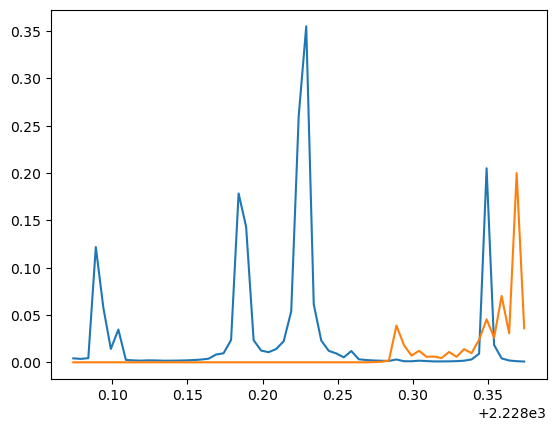

In [181]:
using PyPlot
mFieldScan = [(2228.224 - 0.15):0.005:(2228.224 + 0.15)...]*1e6
statePop4 = [8, 16,  24]
popValues4 = [1, 1, 1]#ones(size(statePop4))#[1]
driveTime = 200e-6
arbScale = 5
using PyPlot
#res = simulateSpectrum(mFieldScan, statePop,popValues,  driveTime, IntensityScan[1].val, IntensityScan[1].vec, Hmol)
res2 = simulateSpectrum(mFieldScan, statePop4,popValues4,  driveTime, IntensityScan[1].val, IntensityScan[1].vec, Hmol)

figure(gcf())


clf()
plot(mFieldScan*1e-6, sum(res2, dims = 1)', label="K = -4")
plot(mFieldScan*1e-6,offRes/arbScale)
figure(gcf())

In [139]:
mean(intDist)

10.695844557763397

In [62]:
using Profile, PProf
Profile.clear();
@profile  wrapIntensity(intDist, IntensityScan, UnitaryDict, Hmol,  mFieldScan,statePop,popValues,  driveTime; truncateEnergy = 20e3)
pprof(;webport=58697)

"profile.pb.gz"

In [ ]:

# Helper struct to hold all working buffers
struct WorkBuffers
    H_full::Matrix{ComplexF64}
    dipole_sum::Matrix{ComplexF64}
    Htrunc::Matrix{ComplexF64}
    stateInit::Vector{ComplexF64}
    stateFinal::Vector{ComplexF64}
    statesTruncated::Vector{Int}
    H0_part::Matrix{ComplexF64}
    Hmicr_scaled::Matrix{ComplexF64}
end

function create_work_buffers(n_states::Int, max_trunc_size::Int=144)
    return WorkBuffers(
        zeros(ComplexF64, n_states, n_states),  # H_full
        zeros(ComplexF64, n_states, n_states),  # dipole_sum
        zeros(ComplexF64, max_trunc_size, max_trunc_size),  # Htrunc
        zeros(ComplexF64, max_trunc_size),  # stateInit
        zeros(ComplexF64, max_trunc_size),  # stateFinal
        zeros(Int, max_trunc_size),  # statesTruncated
        zeros(ComplexF64, n_states, n_states),  # H0_part
        zeros(ComplexF64, n_states, n_states)   # Hmicr_scaled
    )
end

function wrapIntensity2(IntensityDist, IntensityScan, UnitaryDict, Hmol, mField, statePop, popValues, driveTime; truncateEnergy=20e3)
    keyOI2 = [s.Intensity[1] for s in IntensityScan]
    res = zeros(Float64, length(IntensityDist), length(mField))
    
    N_product = Hmol.MolOp.N[1:3] * Hmol.MolOp.N[1:3]
    Hmicr = zeros(Float64, size(N_product))
    Hmicr[findall(x->isapprox(x, 2), N_product)] .= 1

    # Compute E-field
    rotationAngle = 87.5
    Erot = rotation_matrix(axisX, rotationAngle*pi/180)*Ecomp1
    Ecomp = normalize!(Erot) 
    sigmaPcomp = abs(decompose_spherical(Erot)[3])
    PiTime = 398e-6
    rabiRate = 1/(2*PiTime)
    E_field_hz = rabiRate/(0.33*DebyeSI)*(1/sigmaPcomp)
    E_field_res = E_field_hz*Ecomp
    
    stateGS = statePop[1]
    
    # ALLOCATE BUFFERS ONCE
    n_states = size(IntensityScan[1].val, 1)
    buffers = create_work_buffers(n_states)
    
    # PRE-SCALE Hmicr ONCE
    Hmicr_scaled = 2π .* Hmicr
    threshold = truncateEnergy * 2π
    
    # Allocate dipole_sum buffer (reused per intensity)
    dipole_sum = zeros(ComplexF64, n_states, n_states)

    # Single-threaded loop
    for indC in 2:length(IntensityDist)
        IntensityCurrent = IntensityDist[indC]
        
        keyInd2::Int64 = argmin(abs.(keyOI2 .- IntensityCurrent))
        dipOpU = UnitaryDict[IntensityScan[keyInd2].Intensity[1]].dipOpU
        
        # Get H0 and scale it
        H0_diag = IntensityScan[keyInd2].val .- IntensityScan[keyInd2].val[stateGS]
        H0_part_diag = 2π .* H0_diag
        
        # COMPUTE DIPOLE_SUM ONCE PER INTENSITY HERE
        fill!(dipole_sum, 0.0)
        @inbounds for k in 1:3
            @. dipole_sum += E_field_res[k] * dipOpU[k]
        end
        dipole_sum .*= π  # 2π/2

        res[indC, :] = simulateSpectrumWrap_buffered!(
            buffers, mField, statePop, popValues, driveTime,
            Hmicr_scaled, H0_part_diag, dipole_sum, threshold
        )
    end
    
    return res
end
function simulateSpectrumWrap_buffered!(
    buffers::WorkBuffers,
    mField,
    statePop,
    popValues,
    driveTime,
    Hmicr_scaled,
    H0_part_diag,
    dipole_sum,
    threshold
)
    pop_excited = zeros(Float64, length(mField))
    
    @inbounds for (i, m_i) in enumerate(mField)
        for (_ind, stateGS) in enumerate(statePop)
            # Build H_full in-place - use buffers.H_full directly
            @inbounds for j in 1:size(buffers.H_full, 1)
                for k in 1:size(buffers.H_full, 2)
                    buffers.H_full[j, k] = (j == k ? H0_part_diag[j] : 0.0) - m_i * Hmicr_scaled[j, k] + dipole_sum[j, k]
                end
            end
            
            # Find truncated states
            buffers.statesTruncated[1] = stateGS
            n_trunc = 1
            
            for state in 37:144
                if abs(real(buffers.H_full[state, state])) < threshold
                    n_trunc += 1
                    buffers.statesTruncated[n_trunc] = state
                end
            end
            
            # Extract Hamiltonian
            for j_idx in 1:n_trunc
                j = buffers.statesTruncated[j_idx]
                for k_idx in 1:n_trunc
                    k = buffers.statesTruncated[k_idx]
                    buffers.Htrunc[j_idx, k_idx] = buffers.H_full[j, k]
                end
            end
            
            Htrunc_view = @view buffers.Htrunc[1:n_trunc, 1:n_trunc]
            Uprop = exp(-1im * Htrunc_view * driveTime)
            
            fill!(buffers.stateInit, 0.0)
            buffers.stateInit[1] = popValues[_ind]
            stateInit_view = @view buffers.stateInit[1:n_trunc]
            
            stateFinal_view = @view buffers.stateFinal[1:n_trunc]
            mul!(stateFinal_view, Uprop', stateInit_view)
            
            pop_sum = 0.0
            for j in 2:n_trunc
                pop_sum += abs2(buffers.stateFinal[j])
            end
            pop_excited[i] += pop_sum
        end
    end
    
    return pop_excited
end

simulateSpectrumWrap_buffered! (generic function with 2 methods)

In [128]:
res = wrapIntensity2(intDist*1e7, IntensityScan, UnitaryDict, Hmol,  mFieldScan,statePop,popValues,  driveTime; truncateEnergy = 20e3)

10000×61 Matrix{Float64}:
 0.0         0.0          0.0          …  0.0         0.0         0.0
 3.9898e-5   0.000138687  0.00456048      1.54703e-6  1.08724e-5  4.93566e-7
 7.27945e-5  0.000197334  0.00145314      9.39345e-7  1.38884e-5  2.16891e-7
 6.01092e-5  0.00015854   0.00102667      1.50921e-6  1.39484e-5  3.82817e-7
 2.33094e-5  0.00593321   2.04893e-5      1.30842e-5  1.56218e-7  5.3704e-8
 7.16902e-7  9.7185e-6    0.00535696   …  4.30781e-6  8.30612e-6  7.06379e-7
 2.78475e-6  7.64272e-6   2.22479e-5      5.93794e-6  9.98637e-6  4.10505e-6
 8.14088e-5  0.000227563  0.00194141      5.31763e-7  1.36814e-5  1.33847e-7
 8.14088e-5  0.000227563  0.00194141      5.31763e-7  1.36814e-5  1.33847e-7
 3.9898e-5   0.000138687  0.00456048      1.54703e-6  1.08724e-5  4.93566e-7
 ⋮                                     ⋱                          ⋮
 8.11988e-5  0.000243749  0.00302921      3.08027e-7  1.28715e-5  1.73753e-7
 7.51942e-5  0.000406207  0.00469304      8.86484e-6  4.76504e-6  6

In [6]:
using LinearAlgebra, BenchmarkTools
using CUDA   # pkg> add CUDA

N = 1000
A = rand(Float32, N, N)
B = rand(Float32, N, N)

println("CPU matmul:")
@btime eigen(A)

dA = CuArray(A)
dB = CuArray(B)
CUDA.@sync dA * dB  # warm-up

println("GPU matmul:")
@btime CUDA.@sync($dA * $dB);


CPU matmul:
  576.287 ms (39 allocations: 15.80 MiB)
GPU matmul:
  166.600 μs (59 allocations: 1.48 KiB)


In [4]:
using CUDA, LinearAlgebra, BenchmarkTools

N  = 1000
A  = rand(Float32, N, N)
A  = (A + A') / 2

dA = CuArray(A)

# warm up
CUDA.@sync begin
    # if eigen works directly:
    F = eigen(dA)
end

println("GPU eigen (Hermitian):")
@btime CUDA.@sync(eigen($dA));


GPU eigen (Hermitian):
  8.855 ms (127 allocations: 3.50 KiB)


In [3]:
using CUDA, LinearAlgebra, BenchmarkTools

In [93]:
using LinearAlgebra
using Random
using Distributions

# --- Physics / Beam Configuration Struct ---
struct REMPIConfig
    beam_waist::Float64      # e.g. 1.5e-3
    dark_line_radius::Float64 # e.g. 0.1e-3
    max_ionization_prob::Float64 # Max detection efficiency (0.0 to 1.0)
end

function simulateRigorousProductSpectroscopy(
    mFieldScan,       # Vector of B-fields to scan
    statePop,         # Initial state indices (e.g. [2, 10...])
    popValues,        # Initial populations
    t_dark,           # Duration of dark accumulation time
    microwaveTime, 
    step_time,        # Duration of EACH microwave pulse step
    n_steps,          # Number of measure/repeat cycles
    rempi_config::REMPIConfig, # Beam geometry definition
    velocity_func,    # Function returning (vA, vB)
    eigvals, eigvecs, Hmol, # Molecular structure data
    n_particles=100   # Number of Monte Carlo particles per B-field point
)

    # --- 1. Rigorous Microwave Setup (From your snippet) ---
    DebyeSI = 3.33564e-30
    truncate = 144
    
    dipOp = getDipoleMatrix(Hmol.MolOp)
    Hmicr = zeros(Float64, size(dipOp[1]))
    N_product = Hmol.MolOp.N[1:3] * Hmol.MolOp.N[1:3]

    # Transform dipoles to eigenbasis
    dipOpU = [adjoint(eigvecs) * dip * (eigvecs) for dip in dipOp]
    
    # Identify N=2 couplings
    Hmicr[findall(x -> isapprox(x, 2), N_product)] .= 1
    H0 = Diagonal(eigvals)

    # Calculate E-field for pi-time (Your calibration logic)
    rotationAngle = 88.2
    # Assuming standard setup variables (axisX, Ecomp1) are available in global scope or passed
    # For this function to be standalone, you might need to pass Ecomp1/axisX
    # Here I assume they are globally defined as in your notebook
    Erot = rotation_matrix(axisX, rotationAngle * pi/180) * Ecomp1
    Ecomp = normalize!(Erot) 
    sigmaPcomp = abs(decompose_spherical(Erot)[3])
    
    PiTime = (178e-6)/2
    rabiRate = 1/(2*PiTime)
    E_field_hz = rabiRate/(0.33*DebyeSI)*(1/sigmaPcomp)
    E_field_res = E_field_hz * Ecomp
    
    # --- Simulation Storage ---
    # Store total accumulated signal for each state
    totalSignal = zeros(Float64, 36, length(mFieldScan))
    
    indsN1 = 37:144   # N=1 Manifold indices
    statesOI = [1:144...]

    # --- 2. Main Frequency Scan Loop ---
    for (i, m_i) in enumerate(mFieldScan)
        
        # Build Hamiltonian for this specific B-field
        H = 2*pi*(H0 - m_i*Hmicr + sum(E_field_res .* dipOpU)/2)
        Htrunc = H[statesOI, statesOI]
        
        # Create Propagator for ONE step of duration `step_time`
        U_step = exp(-1im * Htrunc * microwaveTime)
        
        # --- 3. Iterate over Initial States ---
        for (_ind, stateGS) in enumerate(statePop)
            
            # --- 4. Monte Carlo Particle Loop ---
            # We average the behavior of n_particles for this specific transition
            
            avg_signal_per_particle = 0.0
            
            for p in 1:n_particles
                # A. Initialize Particle Physics
                # ------------------------------
                # Random velocity for this specific product channel (e.g. K=0, Rb=1)
                # Assuming velocity_func returns magnitude [vA, vB]
                v_mag = velocity_func(0, 1)[1] # Taking product A for now
                
                # Random spawn time in the dark window
                t_spawn = rand() * t_dark
                
                # Random 3D trajectory (Projected onto detection plane)
                theta = acos(2*rand() - 1)
                r_scale_factor = v_mag * sin(theta) # r_proj = v*t * sin(theta)
                
                # B. Initialize Quantum State
                # ---------------------------
                psi = zeros(ComplexF64, size(eigvecs, 1))
                psi[stateGS] = popValues[_ind] # Initialize in ground state
                psi_curr = psi[statesOI]
                
                particle_signal = 0.0
                
                # --- 5. Multi-Step Pulse/Measure Cycle ---
                for step in 1:n_steps
                    # C. Evolve State (Unitary Microwave Drive)
                    psi_curr = U_step * psi_curr
                    
                    # D. Determine Spatial Position
                    # Time elapsed since spawn = (dark_time remaining) + (pulses so far)
                    # Note: We assume measurement happens at the END of the step
                    t_flight = (t_dark - t_spawn) + (step * step_time)
                    
                    r_curr = r_scale_factor * t_flight
                    
                    # E. Calculate Detection Probability (eta)
                    # This replaces the constant "fidelity" from before
                    eta = 0.0
                    if r_curr >= rempi_config.dark_line_radius

                        # Gaussian beam profile wing
                        intensity = exp(-2 * r_curr^2 / rempi_config.beam_waist^2)
                        eta = rempi_config.max_ionization_prob * intensity
                    end
                    
                    # F. Project/Measure
                    # Population in N=1
                    pop_N1 = sum(abs2, psi_curr[indsN1])
                    
                    # Record Signal (Probability of clicking *now*)
                    particle_signal += pop_N1 * eta
                    
                    # G. Back-Action (Collapse)
                    # Remove the detected population from the coherent state
                    # so it can't be detected again or Rabi flop back.
                    scaler = sqrt(1.0 - eta)
                    psi_curr[indsN1] .*= scaler
                end
                
                avg_signal_per_particle += particle_signal
            end
            
            # Save result (Average signal * number of simulated events if comparing to experiment)
            # Here we just store the average probability sum
            totalSignal[stateGS, i] = avg_signal_per_particle / n_particles
        end
    end

    return totalSignal
end

simulateRigorousProductSpectroscopy (generic function with 4 methods)

In [92]:

function VelocityPairKRbRb(NKRb, FRb)
    BKRb = 2.2227/2

    Uatom = FRb == 2 ? 6.628 : 0
    Umol = BKRb*NKRb*(NKRb + 1)
    Upot = Uatom + Umol
    exergonic =  0.05#6.628#6.628  
    amu2kg = 1.66054e-27
    convFac = PlanckConstant.val*1e9
    mKRb, mRb = (40 + 87)*amu2kg,(87)*amu2kg
    return [sqrt(2*mRb/(mKRb*(mKRb + mRb))*(exergonic-Upot)*convFac), sqrt(2*mKRb/(mRb*(mKRb + mRb))*(exergonic-Upot)*convFac)]
end

# 1. Define the Detection Geometry
# Waist 1.5mm, Dark Line 100um, Max detection efficiency 10%
rempi_cfg = REMPIConfig(1.5e-3, 0.1e-3, 0.1) 

# 2. Define Timing
t_dark = 30e-6      # 50 us accumulation
microwaveTime = 10e-6   # 10 us microwave pulses
step_time = 50e-6
n_steps = 200         # 6 cycles

# 3. Run Simulation
# Note: n_particles determines noise vs speed. 
# 50-100 is usually enough for a smooth-ish spectrum.
res_rigorous = simulateRigorousProductSpectroscopy(
    mFieldScan, 
    statePop, 
    popValues, 
    t_dark, 
    microwaveTime, 
    step_time,
    n_steps, 
    rempi_cfg, 
    VelocityPairKRbRb, # Pass your existing velocity function
    IntensityScan[1].val, # Eigvals
    IntensityScan[1].vec, # Eigvecs
    Hmol,
    100 # n_particles
)

# 4. Plot
clf()
plot(mFieldScan*1e-6, sum(res_rigorous, dims=1)', label="Rigorous Product Sim")
legend()
figure(gcf())

InterruptException: InterruptException:

In [90]:
50e-6*200*VelocityPairKRbRb(0, 1)*1e6

2-element Vector{Float64}:
 3573.997324701808
 5217.214485484249

In [198]:
using LinearAlgebra
using Random
using Base.Threads

function simulateBatchedSpectrum(
    mFieldScan,       
    statePop,         
    popValues,        
    t_dark,        
    microwaveTime,    
    step_time,        
    n_steps,          
    rempi_config, 
    velocity_func,    
    eigvals, eigvecs, Hmol, 
    n_particles=100
)
    old_blas_threads = BLAS.get_num_threads()
    BLAS.set_num_threads(1)


    try 
        # --- Setup Constants ---
        DebyeSI = 3.33564e-30
        indsN1 = 37:144   
        statesOI = 1:144
        n_states = length(statesOI)
        
        # Pre-calculate Dipoles & H indices
        dipOp = getDipoleMatrix(Hmol.MolOp)
        dipOpU = [adjoint(eigvecs) * dip * (eigvecs) for dip in dipOp]
        N_product = Hmol.MolOp.N[1:3] * Hmol.MolOp.N[1:3]
        micr_inds = findall(x -> isapprox(x, 2), N_product)
        
        # Pre-calculate Rabi Field
        rotationAngle = 88.2
        # Ensure Ecomp1/axisX are defined
        Erot = rotation_matrix(axisX, rotationAngle * pi/180) * Ecomp1
        Ecomp = normalize!(Erot) 
        sigmaPcomp = abs(decompose_spherical(Erot)[3])
        rabiRate = 1/(2 * (178e-6)/2)
        E_field_res = (rabiRate/(0.33*DebyeSI)*(1/sigmaPcomp)) * Ecomp
        
        H_rabi_term = sum(E_field_res .* dipOpU)/2
        H0 = Diagonal(eigvals)
        Hmicr_template = zeros(Float64, size(dipOp[1]))
        Hmicr_template[micr_inds] .= 1.0

        # --- Pre-Calculate Trajectories (The eta matrix) ---
        # etas[particle, step]
        etas = zeros(Float64, n_particles, n_steps)
        for p in 1:n_particles
            v_mag = velocity_func(0, 1)[1]
            t_spawn = rand() * t_dark
            # Projected radial expansion factor
            r_scale = v_mag * sin(acos(2*rand()-1)) 
            
            for s in 1:n_steps
                t_flight = (t_dark - t_spawn) + ((s-1) * step_time)
                r = r_scale * t_flight
                if r >= rempi_config.dark_line_radius
                    etas[p, s] = rempi_config.max_ionization_prob * exp(-2 * r^2 / rempi_config.beam_waist^2)
                end
            end
        end
        println("COmpleted Precalculation of Trajectories")
        # --- Storage ---
        totalSignal = zeros(Float64, 36, length(mFieldScan))

        # --- Parallel Scan ---
        @threads for i in 1:length(mFieldScan)
            m_i = mFieldScan[i]
            
            # 1. Build H & Propagator
            H = H0 .- (m_i .* Hmicr_template) .+ H_rabi_term
            H .*= 2*pi
            U_step = exp(-1im * H[statesOI, statesOI] * microwaveTime)
            
            # 2. Iterate Initial States
            for (pop_idx, stateGS) in enumerate(statePop)
                
                # --- BATCHING MAGIC STARTS HERE ---
                
                # Create a State Matrix: (144 rows x n_particles columns)
                # Two buffers for ping-pong (avoid allocation in loop)
                psi_curr = zeros(ComplexF64, n_states, n_particles)
                psi_next = zeros(ComplexF64, n_states, n_particles)
                
                # Initialize all particles to the ground state
                psi_curr[stateGS, :] .= popValues[pop_idx]
                
                accumulated_signal = 0.0
                
                for step in 1:n_steps
                    # A. Matrix-Matrix Multiplication (BLAS Level 3)
                    # This is the massive speedup. 
                    # mul!(dest, A, B) computes dest = A*B in place.
                    mul!(psi_next, U_step, psi_curr)
                    
                    # B. Batch Projection & Measurement
                    # We iterate columns because each particle has a unique 'eta'
                    # (This loop is fast because operations are simple scalar math)
                    for p in 1:n_particles
                        eta = etas[p, step]
                        
                        # Calculate population in N=1 for this particle
                        # Optimization: view avoids slicing allocation
                        pop_N1 = sum(abs2, @view psi_next[indsN1, p])
                        
                        accumulated_signal += pop_N1 * eta
                        
                        # Zeno Projection (Back-action)
                        if eta > 1e-6
                            scaler = sqrt(1.0 - eta)
                            @views psi_next[indsN1, p] .*= scaler
                        end
                    end
                    
                    # Swap buffers for next step (psi_next becomes psi_curr)
                    psi_curr, psi_next = psi_next, psi_curr
                end
                
                totalSignal[stateGS, i] = accumulated_signal / n_particles
            end
        end

        return totalSignal
    finally
        # Always restore previous settings, even if code crashes
        BLAS.set_num_threads(old_blas_threads)
    end
end

simulateBatchedSpectrum (generic function with 2 methods)

In [99]:
println("y")

y


COmpleted Precalculation of Trajectories
COmpleted Precalculation of Trajectories


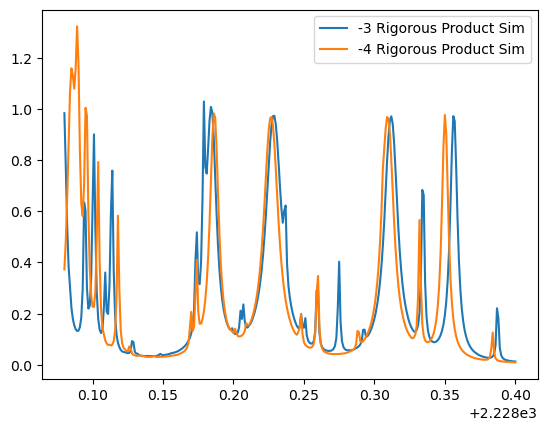

In [201]:
mFieldScan = [2228.08:0.001:2228.4...]*1e6
statePop4 = [1, 8, 16,  24]
popValues4 = ones(size(statePop4))#[1]
statePop = [2, 10,18,  26]
popValues = ones(size(statePop))#[1]


function VelocityPairKRbRb(NKRb, FRb)
    BKRb = 2.2227/2

    Uatom = FRb == 2 ? 6.628 : 0
    Umol = BKRb*NKRb*(NKRb + 1)
    Upot = Uatom + Umol
    exergonic =  0.05#6.628#6.628  
    amu2kg = 1.66054e-27
    convFac = PlanckConstant.val*1e9
    mKRb, mRb = (40 + 87)*amu2kg,(87)*amu2kg
    return [sqrt(2*mRb/(mKRb*(mKRb + mRb))*(exergonic-Upot)*convFac), sqrt(2*mKRb/(mRb*(mKRb + mRb))*(exergonic-Upot)*convFac)]
end

# 1. Define the Detection Geometry
# Waist 1.5mm, Dark Line 100um, Max detection efficiency 10%
rempi_cfg = REMPIConfig(1.5e-3, 0.1e-3, 0.1) 

# 2. Define Timing
t_dark = 20e-6      # 50 us accumulation
microwaveTime = 10e-6   # 10 us microwave pulses
step_time = 50e-6
n_steps = 200         # 6 cycles

# 3. Run Simulation
# Note: n_particles determines noise vs speed. 
# 50-100 is usually enough for a smooth-ish spectrum.
res_rigorous = simulateBatchedSpectrum(
    mFieldScan, 
    statePop, 
    popValues, 
    t_dark, 
    microwaveTime, 
    step_time,
    n_steps, 
    rempi_cfg, 
    VelocityPairKRbRb, # Pass your existing velocity function
    IntensityScan[1].val, # Eigvals
    IntensityScan[1].vec, # Eigvecs
    Hmol,
    100 # n_particles
)

res_rigorous2 = simulateBatchedSpectrum(
    mFieldScan, 
    statePop4, 
    popValues4, 
    t_dark, 
    microwaveTime, 
    step_time,
    n_steps, 
    rempi_cfg, 
    VelocityPairKRbRb, # Pass your existing velocity function
    IntensityScan[1].val, # Eigvals
    IntensityScan[1].vec, # Eigvecs
    Hmol,
    100 # n_particles
)

# 4. Plot
clf()
plot(mFieldScan*1e-6, sum(res_rigorous, dims=1)', label="-3 Rigorous Product Sim")
plot(mFieldScan*1e-6, sum(res_rigorous2, dims=1)', label="-4 Rigorous Product Sim")
legend()
figure(gcf())

In [159]:
VelocityPairKRbRb(0, 1)*1/2e3*1e6*5

2-element Vector{Float64}:
  893.499331175452
 1304.303621371062

In [191]:
using LinearAlgebra
using Random
using Base.Threads
#using DifferentialEquations
using Interpolations # You may need to add this package

# --- 1. Physics Structs (From your Notebook) ---
struct REMPI_Beam
    targetState::Int
    beamCenter::Vector{Float64}
    kvec::Vector{Float64}
    pulseWidth::Float64
    ionizationProb::Float64
    waist::Float64
    Ω::Float64
    Γion::Float64
    Γdecay::Float64
    Δ::Float64    
end

struct ReactionPair
   statePair
   vA
   vB
   spawnTime
   y0::Vector{ComplexF64}
end

# --- 2. The Differential Equation (From your Notebook) ---
# Simplified to focus on the physics of one beam acting on one particle
function REMPI_DiffEq_Internal(dy, y, p, t)
    # Unpack parameters: p = (BeamStruct)
    beam = p
    
    # We assume the particle is effectively stationary during the nanosecond pulse
    # So we treat Omega as constant for this specific integration step
    Ω_i = beam.Ω # This will be the LOCAL Omega passed in the solver
    
    # y[1] = Ground State Amplitude
    # y[2] = Intermediate State Amplitude
    # y[3] = Ion Population (Accumulated)
    
    # Dynamics (Reproducing the logic from your snippet)
    # Ground <-> Intermediate coupling
    dy[1] = -0.5im * (Ω_i * y[2] - conj(Ω_i * y[2]))
    
    # Intermediate State (Decay + Ionization + Coupling)
    dy[2] = -0.5 * (beam.Γdecay + beam.Γion) * y[2] + 
             0.5im * Ω_i * (y[1]) # Simplified coupling term
             # Note: Your notebook had complex conjugate terms that imply 
             # equations for real/imag parts or specific Hamiltonian form. 
             # Standard Rabi-Ionization form:
             # d_cg = i(W/2)ce
             # d_ce = i(W/2)cg - (G/2)ce
             # d_Pion = G_ion * |ce|^2
             
    # Ion Accumulation
    # Assuming y[3] is Population, not amplitude
    dy[3] = beam.Γion * abs2(y[2]) 
end

# --- 3. Pre-Computer: Generate Lookup Table ---
function generate_rempi_lookup(max_rabi, pulse_width, gamma_ion, gamma_decay)
    # Define a range of Rabi frequencies to scan (0 to Max)
    # We use sqrt scaling to have more resolution at low intensities
    omegas = range(0, max_rabi, length=100)
    
    ion_probs = zeros(Float64, length(omegas))
    surv_probs = zeros(Float64, length(omegas))
    
    y0 = ComplexF64[1.0, 0.0, 0.0] # Start in Ground State
    tspan = (0.0, pulse_width)
    
    for (i, om) in enumerate(omegas)
        if om == 0
            ion_probs[i] = 0.0
            surv_probs[i] = 1.0
            continue
        end
        
        # Create a temp beam struct for the solver
        # We only care about Omega, Gamma, Decay here
        # Dummy values for spatial stuff
        beam_params = REMPI_Beam(0, [0.0], [0.0], pulse_width, 0.0, 0.0, om, gamma_ion, gamma_decay, 0.0)
        
        prob = ODEProblem(REMPI_DiffEq_Internal, y0, tspan, beam_params)
        sol = DifferentialEquations.solve(prob, Tsit5(), save_everystep=false, verbose=false)
        
        # Extract Results at end of pulse
        final_state = sol.u[end]
        
        # Ion Yield (y[3] is population)
        ion_probs[i] = real(final_state[3])
        
        # Ground State Survival (Remaining population in y[1])
        surv_probs[i] = abs2(final_state[1])
    end
    
    # Create Interpolators
    itp_ion = LinearInterpolation(omegas, ion_probs, extrapolation_bc=Flat())
    itp_surv = LinearInterpolation(omegas, surv_probs, extrapolation_bc=Flat())
    
    return itp_ion, itp_surv
end



# --- 4. The Main Simulation ---

function simulateBatchedSpectrum3(
    mFieldScan,       
    statePop,         
    popValues,        
    t_dark,        
    microwaveTime, # Duration of microwave drive
    step_time,     # Duration of ONE full cycle (Microwave + REMPI + Dark)   
    n_steps,          
    rempi_config, 
    velocity_func,    
    eigvals, eigvecs, Hmol, 
    n_particles=100
)
    old_blas_threads = BLAS.get_num_threads()
    BLAS.set_num_threads(1)

    try 
        # --- A. Setup Physics & Constants ---
        DebyeSI = 3.33564e-30
        indsN1 = 37:144   
        statesOI = 1:144
        n_states = length(statesOI)
        
        # 1. Hamiltonian Prep
        dipOp = getDipoleMatrix(Hmol.MolOp)
        dipOpU = [adjoint(eigvecs) * dip * (eigvecs) for dip in dipOp]
        N_product = Hmol.MolOp.N[1:3] * Hmol.MolOp.N[1:3]
        micr_inds = findall(x -> isapprox(x, 2), N_product)
        
        rotationAngle = 88.2
        Erot = rotation_matrix(axisX, rotationAngle * pi/180) * Ecomp1
        Ecomp = normalize!(Erot) 
        sigmaPcomp = abs(decompose_spherical(Erot)[3])
        rabiRate = 1/(2 * (177e-6)/2)
        E_field_res = (rabiRate/(0.33*DebyeSI)*(1/sigmaPcomp)) * Ecomp
        H_rabi_term = sum(E_field_res .* dipOpU)/2
        H0 = Diagonal(eigvals)
        Hmicr_template = zeros(Float64, size(dipOp[1]))
        Hmicr_template[micr_inds] .= 1.0

        # --- B. Rigorous REMPI Pre-Calculation ---
        println("Generatng REMPI Lookup Table...")
        # Extract params from config (assuming rempi_config holds these now)
        # You can tune these to match your notebook EXACTLY
        Gamma_Ion = 14e6 * 2 * pi   # 14 MHz
        Gamma_Decay = 14e6 * 2 * pi
        Max_Rabi = 15e6 * 2 * pi    # 15 MHz
        Pulse_Width = 50e-9         # 50 ns
        
        itp_ion, itp_surv = generate_rempi_lookup(Max_Rabi, Pulse_Width, Gamma_Ion, Gamma_Decay)
        
        # --- C. Pre-Calculate Particle Trajectories ---
        # Instead of storing 'eta' (linear probability), we store 'Omega' (Rabi Freq)
        # We will look up the physics later.
        
        omegas_experienced = zeros(Float64, n_particles, n_steps)
        
        for p in 1:n_particles
            v_mag = velocity_func(0, 1)[1]
            t_spawn = rand() * t_dark
            r_scale = v_mag * sin(acos(2*rand()-1)) 
            
            for s in 1:n_steps
                # Time when the pulse actually hits
                t_flight = (t_dark - t_spawn) + ((s-1) * step_time)
                r = r_scale * t_flight
                
                # Dark Line Logic
                if r >= rempi_config.dark_line_radius
                    # Calculate LOCAL Rabi Frequency
                    # Gaussian Profile: Ω(r) = Ω_max * exp(-r^2/w^2)
                    # Note: Intensity is exp(-2r^2/w^2), Omega scales as sqrt(I), so exp(-r^2/w^2)
                    # Use the correct scaling for your definition of "waist"
                    omegas_experienced[p, s] = Max_Rabi * exp(-1.0 * r^2 / rempi_config.beam_waist^2)
                else
                    omegas_experienced[p, s] = 0.0
                end
            end
        end
        println("Trajectory Pre-calculation Complete.")

        # --- D. Parallel Scan ---
        totalSignal = zeros(Float64, 36, length(mFieldScan))

        @threads for i in 1:length(mFieldScan)
            m_i = mFieldScan[i]
            
            # 1. Build H & Propagator
            H = H0 .- (m_i .* Hmicr_template) .+ H_rabi_term
            H .*= 2*pi
            U_step = exp(-1im * H[statesOI, statesOI] * microwaveTime)
            
            # 2. Iterate Initial States
            for (pop_idx, stateGS) in enumerate(statePop)
                
                # Batch buffers
                psi_curr = zeros(ComplexF64, n_states, n_particles)
                psi_next = zeros(ComplexF64, n_states, n_particles)
                
                psi_curr[stateGS, :] .= popValues[pop_idx]
                
                accumulated_signal = 0.0
                
                for step in 1:n_steps
                    # 1. Unitary Evolution (Microwave)
                    mul!(psi_next, U_step, psi_curr)
                    
                    # 2. Batch REMPI Detection (ODE Lookup)
                    for p in 1:n_particles
                        # Retrieve the local Rabi frequency this particle sees
                        om_local = omegas_experienced[p, step]
                        
                        # Lookup Physics
                        # A. Ionization Yield (Signal)
                        eta = itp_ion(om_local)
                        
                        # B. Ground State Survival (Back-action)
                        # Fraction of population that stays in N=1 (didn't decay/ionize)
                        survival_frac = itp_surv(om_local)
                        
                        # Calculate N=1 Population
                        pop_N1 = sum(abs2, @view psi_next[indsN1, p])
                        
                        # Add Signal
                        accumulated_signal += pop_N1 * eta
                        
                        # Apply Back-action (Project out lost population)
                        # We scale amplitude by sqrt(survival_probability)
                        if survival_frac < 0.999
                             scaler = sqrt(survival_frac)
                            @views psi_next[indsN1, p] .*= scaler
                        end
                    end
                    
                    psi_curr, psi_next = psi_next, psi_curr
                end
                
                totalSignal[stateGS, i] = accumulated_signal / n_particles
            end
        end

        return totalSignal
    finally
        BLAS.set_num_threads(old_blas_threads)
    end
end

simulateBatchedSpectrum3 (generic function with 2 methods)

Generatng REMPI Lookup Table...
Trajectory Pre-calculation Complete.
Generatng REMPI Lookup Table...
Trajectory Pre-calculation Complete.


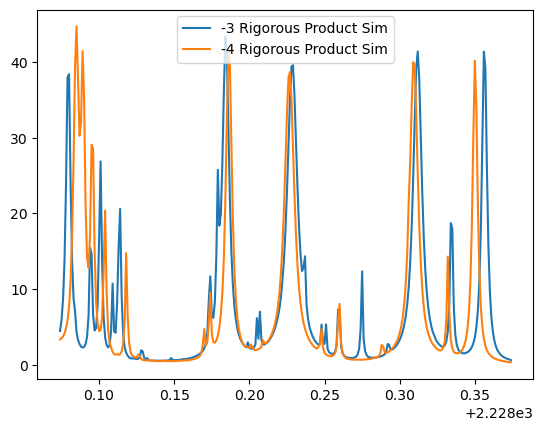

In [192]:
mFieldScan = [(2228.224- 0.15):0.001:(2228.224 +  0.15)...]*1e6
statePop4 = [1,   8, 16, 24]
popValues4 = ones(size(statePop4))#[1]
statePop = [2, 10,18,  26]
popValues = ones(size(statePop))#[1]


function VelocityPairKRbRb(NKRb, FRb)
    BKRb = 2.2227/2

    Uatom = FRb == 2 ? 6.628 : 0
    Umol = BKRb*NKRb*(NKRb + 1)
    Upot = Uatom + Umol
    exergonic =  0.05#6.628#6.628  
    amu2kg = 1.66054e-27
    convFac = PlanckConstant.val*1e9
    mKRb, mRb = (40 + 87)*amu2kg,(87)*amu2kg
    return [sqrt(2*mRb/(mKRb*(mKRb + mRb))*(exergonic-Upot)*convFac), sqrt(2*mKRb/(mRb*(mKRb + mRb))*(exergonic-Upot)*convFac)]
end

# 1. Define the Detection Geometry
# Waist 1.5mm, Dark Line 100um, Max detection efficiency 10%
rempi_cfg = REMPIConfig(0.75e-3, 0.1e-3, 0.1) 

# 2. Define Timing
t_dark = 20e-6      # 50 us accumulation
microwaveTime = 10e-6   # 10 us microwave pulses
step_time = 50e-6
n_steps = 200         # 6 cycles

# 3. Run Simulation
# Note: n_particles determines noise vs speed. 
# 50-100 is usually enough for a smooth-ish spectrum.
res_rigorous = simulateBatchedSpectrum3(
    mFieldScan, 
    statePop, 
    popValues, 
    t_dark, 
    microwaveTime, 
    step_time,
    n_steps, 
    rempi_cfg, 
    VelocityPairKRbRb, # Pass your existing velocity function
    IntensityScan[1].val, # Eigvals
    IntensityScan[1].vec, # Eigvecs
    Hmol,
    100 # n_particles
)

res_rigorous2 = simulateBatchedSpectrum3(
    mFieldScan, 
    statePop4, 
    popValues4, 
    t_dark, 
    microwaveTime, 
    step_time,
    n_steps, 
    rempi_cfg, 
    VelocityPairKRbRb, # Pass your existing velocity function
    IntensityScan[1].val, # Eigvals
    IntensityScan[1].vec, # Eigvecs
    Hmol,
    100 # n_particles
)
# 4. Plot
clf()
plot(mFieldScan*1e-6, sum(res_rigorous, dims=1)', label="-3 Rigorous Product Sim")
plot(mFieldScan*1e-6, sum(res_rigorous2, dims=1)', label="-4 Rigorous Product Sim")
legend()
figure(gcf())